Dataset shape: (81343, 20)
PCA Components Shape: (81343, 3)


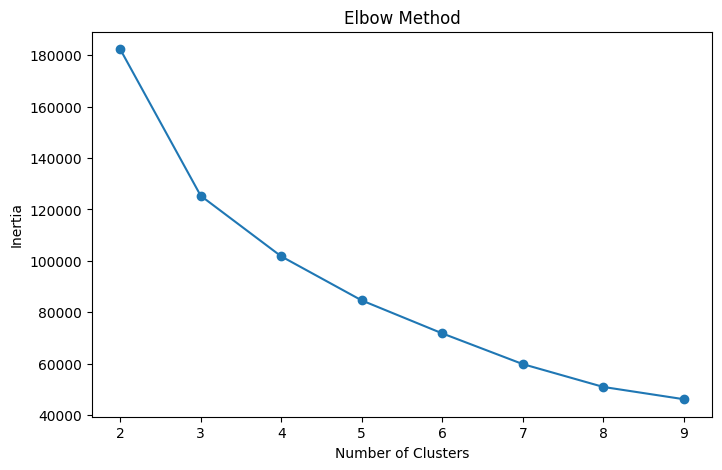


Model Evaluation
----------------------
Silhouette Score: 0.38660068193937647
Davies-Bouldin Score: 0.9485877795157994
Calinski-Harabasz Score: 107176.38327065895

Cluster Distribution:
cluster
0    28159
4    16680
5    13881
3    10811
1     6216
2     5596
Name: count, dtype: int64

Cluster Profile:
           energy   valence  danceability  acousticness
cluster                                                
0        0.721355  0.603899      0.662478      0.202967
1        0.236592  0.170171      0.336812      0.784332
2        0.727559  0.476958      0.505428      0.388855
3        0.734889  0.382399      0.595206      0.146013
4        0.416618  0.322363      0.464220      0.594155
5        0.785683  0.536069      0.557489      0.184436

Training Complete.
Models saved successfully.


In [7]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
import joblib


# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("data/train.csv")

df = df.drop(columns=["Unnamed: 0"])
df = df.dropna()
df = df.drop_duplicates(subset=["track_name","artists"])
print("Dataset shape:", df.shape)


# ==============================
# 3. Feature Selection
# ==============================
features = df[
[
'energy',
'valence',
'danceability',
'acousticness',
'instrumentalness',
'liveness'
]
]


# ==============================
# 4. Feature Scaling
# ==============================
scaler = RobustScaler()

scaled_features = scaler.fit_transform(features)


# ==============================
# 5. PCA (3 components)
# ==============================
pca = PCA(n_components=3)

pca_features = pca.fit_transform(scaled_features)

print("PCA Components Shape:", pca_features.shape)


# ==============================
# 6. Elbow Method (Optional Visualization)
# ==============================
inertia = []
K_range = range(2, 10)

for k in K_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(pca_features)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


# ==============================
# 7. Train Final Model (6 clusters)
# ==============================
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=50,
    max_iter=500
)

clusters = kmeans.fit_predict(pca_features)

df["cluster"] = clusters


# ==============================
# 8. Model Evaluation
# ==============================
sil_score = silhouette_score(pca_features, clusters)
db_score = davies_bouldin_score(pca_features, clusters)
ch_score = calinski_harabasz_score(pca_features, clusters)

print("\nModel Evaluation")
print("----------------------")
print("Silhouette Score:", sil_score)
print("Davies-Bouldin Score:", db_score)
print("Calinski-Harabasz Score:", ch_score)


# ==============================
# 9. Cluster Distribution
# ==============================
print("\nCluster Distribution:")
print(df["cluster"].value_counts())


# ==============================
# 10. Cluster Profile
# ==============================
cluster_profile = df.groupby("cluster")[[
"energy",
"valence",
"danceability",
"acousticness"
]].mean()

print("\nCluster Profile:")
print(cluster_profile)


# ==============================
# 11. Train Recommendation Model
# ==============================
nn_model = NearestNeighbors(
    n_neighbors=10,
    metric='cosine',
    algorithm='brute'
)

nn_model.fit(pca_features)


# ==============================
# 12. Recommendation Function
# ==============================
def recommend(song_index):

    cluster_id = df.iloc[song_index]["cluster"]

    cluster_songs = df[df["cluster"] == cluster_id]

    cluster_indices = cluster_songs.index

    distances, indices = nn_model.kneighbors([pca_features[song_index]])

    recommended = [i for i in indices[0] if i in cluster_indices][:10]

    return df.loc[recommended][["track_name","artists"]]


# ==============================
# 13. Save Models
# ==============================
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca_model.pkl")
joblib.dump(nn_model, "nn_model.pkl")


# ==============================
# 14. Save Clustered Dataset
# ==============================
df.to_csv("clustered_songs.csv", index=False)

print("\nTraining Complete.")
print("Models saved successfully.")